# Лабораторная работа 8


# Обход бинарного дерева поиска. Поиск максимального и минимального значений

## Задание 8.1. Центрированный обход бинарного дерева поиска

In [1]:
import random as rnd
import matplotlib.pyplot as plt

In [2]:
class EmptyNode:
    def __repr__(self):
        return '*'
    
    def insert(self, value):
        return BinaryNode(self, value, self)
    
    def __contains__(self, value):
        return False
    
    def __len__(self):
        return 0
    
    def lcr(self):
        """Центрированный обход для пустого узла — возвращает пустой список"""
        return []


class BinaryNode:
    numberOfNodes = 0
    
    def __init__(self, left, value, right):
        self.left = left
        self.value = value
        self.right = right
        BinaryNode.numberOfNodes += 1
    
    def __repr__(self):
        return f'({self.left},{self.value},{self.right})'
    
    def insert(self, value):
        if value < self.value:
            self.left = self.left.insert(value)
        elif value > self.value:
            self.right = self.right.insert(value)
        return self
    
    def __contains__(self, value):
        if value == self.value:
            return True
        elif value < self.value:
            return value in self.left
        else:
            return value in self.right
    
    def __len__(self):
        return BinaryNode.numberOfNodes
    
    def lcr(self):
        """
        Центрированный обход (LCR - Left, Center, Right).
        Возвращает список значений вершин дерева, отсортированных по возрастанию.
        
        Порядок обхода:
        1. Рекурсивно обойти левое поддерево (L)
        2. Добавить значение текущего узла (C)
        3. Рекурсивно обойти правое поддерево (R)
        """
        result = []
        result.extend(self.left.lcr())   # L - левое поддерево
        result.append(self.value)        # C - текущий узел
        result.extend(self.right.lcr())  # R - правое поддерево
        return result


class BinaryTree:
    def __init__(self):
        self.root = EmptyNode()
        BinaryNode.numberOfNodes = 0
    
    def __repr__(self):
        return repr(self.root)
    
    def insert(self, value):
        self.root = self.root.insert(value)
    
    def __contains__(self, value):
        return value in self.root
    
    def __len__(self):
        return len(self.root)
    
    def lcr(self):
        """
        Центрированный обход бинарного дерева поиска.
        Возвращает список значений вершин дерева, отсортированных по возрастанию.
        """
        return self.root.lcr()

In [3]:
source_data = [rnd.uniform(0, 100) for i in range(10**3)]

print(f"Длина списка source_data: {len(source_data)}")
print(f"Первые 10 элементов: {source_data[:10]}")

Длина списка source_data: 1000
Первые 10 элементов: [51.04503271567711, 50.85416922970754, 75.72558204345124, 71.23920235097623, 11.930140843299352, 25.317593973539076, 81.50575829995907, 18.874694064836163, 21.4171636778125, 78.48491510428471]


In [4]:
tree = BinaryTree()
for i in source_data:
 tree.insert(i)

In [6]:
sorted_data = tree.lcr()

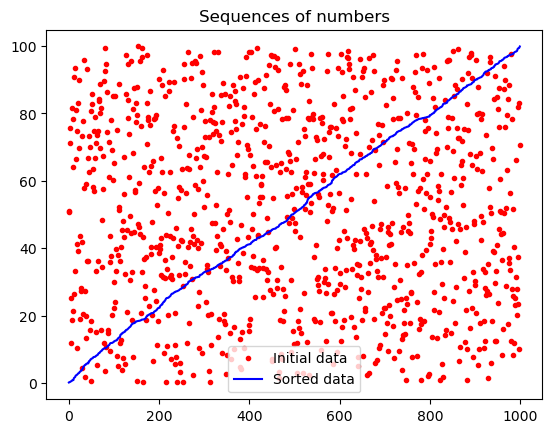

In [7]:
plt.plot(source_data,'r.', label='Initial data')
plt.plot(sorted_data,color='blue',label='Sorted data')
plt.title('Sequences of numbers')
plt.legend()

## Задание 8.2. Нахождение минимального и максимального значения

In [10]:
class EmptyNode:
    def __repr__(self):
        return '*'
    
    def insert(self, value):
        return BinaryNode(self, value, self)
    
    def __contains__(self, value):
        return False
    
    def __len__(self):
        return 0
    
    def lcr(self):
        """Центрированный обход для пустого узла — возвращает пустой список"""
        return []
    
    def min(self):
        """
        Поиск минимального значения в пустом поддереве.
        Для пустого узла минимум не определён, возвращаем None.
        """
        return None
    
    def max(self):
        """
        Поиск максимального значения в пустом поддереве.
        Для пустого узла максимум не определён, возвращаем None.
        """
        return None


class BinaryNode:
    numberOfNodes = 0
    
    def __init__(self, left, value, right):
        self.left = left
        self.value = value
        self.right = right
        BinaryNode.numberOfNodes += 1
    
    def __repr__(self):
        return f'({self.left},{self.value},{self.right})'
    
    def insert(self, value):
        if value < self.value:
            self.left = self.left.insert(value)
        elif value > self.value:
            self.right = self.right.insert(value)
        return self
    
    def __contains__(self, value):
        if value == self.value:
            return True
        elif value < self.value:
            return value in self.left
        else:
            return value in self.right
    
    def __len__(self):
        return BinaryNode.numberOfNodes
    
    def lcr(self):
        """Центрированный обход (LCR) — возвращает отсортированный список"""
        result = []
        result.extend(self.left.lcr())
        result.append(self.value)
        result.extend(self.right.lcr())
        return result
    
    def min(self):
        """
        Поиск минимального значения в поддереве.
        В бинарном дереве поиска минимальный элемент находится 
        в самом левом узле.
        """
        if isinstance(self.left, EmptyNode):
            # Если левый потомок пустой, то текущий узел — минимальный
            return self.value
        else:
            # Иначе рекурсивно ищем минимум в левом поддереве
            return self.left.min()
    
    def max(self):
        """
        Поиск максимального значения в поддереве.
        В бинарном дереве поиска максимальный элемент находится 
        в самом правом узле.
        """
        if isinstance(self.right, EmptyNode):
            # Если правый потомок пустой, то текущий узел — максимальный
            return self.value
        else:
            # Иначе рекурсивно ищем максимум в правом поддереве
            return self.right.max()


class BinaryTree:
    def __init__(self):
        self.root = EmptyNode()
        BinaryNode.numberOfNodes = 0
    
    def __repr__(self):
        return repr(self.root)
    
    def insert(self, value):
        self.root = self.root.insert(value)
    
    def __contains__(self, value):
        return value in self.root
    
    def __len__(self):
        return len(self.root)
    
    def lcr(self):
        """Центрированный обход дерева"""
        return self.root.lcr()
    
    def min(self):
        """
        Возвращает минимальное значение в дереве.
        Если дерево пустое, возвращает None.
        """
        return self.root.min()
    
    def max(self):
        """
        Возвращает максимальное значение в дереве.
        Если дерево пустое, возвращает None.
        """
        return self.root.max()

In [18]:
source_data = [rnd.uniform(0, 100) for i in range(10**3)]

tree = BinaryTree()
for value in source_data:
    tree.insert(value)

print(f"Количество узлов в дереве: {len(tree)}")

Количество узлов в дереве: 1000


In [19]:
# Получаем минимум и максимум из дерева
tree_min = tree.min()
tree_max = tree.max()

print(f"Метод tree.min(): {tree_min}")
print(f"Метод tree.max(): {tree_max}")
print()

python_min = min(source_data)
python_max = max(source_data)

print(f"Встроенная min(source_data): {python_min}")
print(f"Встроенная max(source_data): {python_max}")
print()


Метод tree.min(): 0.013721149271683775
Метод tree.max(): 99.94189189014978

Встроенная min(source_data): 0.013721149271683775
Встроенная max(source_data): 99.94189189014978



## Задание 8.3. Создание модуля

In [25]:
%%writefile binaryTree.py
"""
Модуль binaryTree.py - реализация бинарного дерева поиска.

Этот модуль предоставляет три класса для работы с бинарным деревом поиска:
- EmptyNode: класс-заглушка для представления пустого узла
- BinaryNode: класс узла, содержащего значение и ссылки на потомков
- BinaryTree: основной класс для управления деревом

Основные возможности:
- Вставка элементов (insert)
- Проверка наличия элемента (оператор in)
- Получение количества элементов (len)
- Центрированный обход (lcr) - возвращает отсортированный список
- Поиск минимального и максимального элементов (min, max)
"""


class EmptyNode:
    """
    Класс, представляющий пустой узел (заглушку) в бинарном дереве поиска.
    
    Этот класс используется вместо None для упрощения рекурсивных операций.
    Пустой узел не содержит значения и не имеет потомков.
    Все его методы возвращают значения по умолчанию.
    """
    
    def __repr__(self) -> str:
        """
        Возвращает строковое представление пустого узла.
        
        Returns
        -------
        str
            Символ '*', обозначающий пустой узел.
        """
        return '*'
    
    def insert(self, value):
        """
        Вставляет значение в пустой узел.
        
        При вставке в пустой узел создаётся новый узел BinaryNode
        с заданным значением и пустыми левым и правым потомками.
        
        Parameters
        ----------
        value : any
            Значение для вставки (должно поддерживать операции сравнения).
        
        Returns
        -------
        BinaryNode
            Новый узел с заданным значением и пустыми потомками.
        """
        return BinaryNode(self, value, self)
    
    def __contains__(self, value) -> bool:
        """
        Проверяет наличие значения в пустом узле.
        
        Parameters
        ----------
        value : any
            Значение для проверки (не используется).
        
        Returns
        -------
        bool
            Всегда возвращает False, так как пустой узел не содержит значений.
        """
        return False
    
    def __len__(self) -> int:
        """
        Возвращает количество узлов в пустом поддереве.
        
        Returns
        -------
        int
            0, так как пустой узел не содержит узлов.
        """
        return 0
    
    def lcr(self) -> list:
        """
        Выполняет центрированный обход пустого поддерева.
        
        Returns
        -------
        list
            Пустой список, так как в пустом узле нет значений.
        """
        return []
    
    def min(self):
        """
        Находит минимальное значение в пустом поддереве.
        
        Returns
        -------
        None
            В пустом поддереве нет минимального значения.
        """
        return None
    
    def max(self):
        """
        Находит максимальное значение в пустом поддереве.
        
        Returns
        -------
        None
            В пустом поддереве нет максимального значения.
        """
        return None


class BinaryNode:
    """
    Класс, представляющий узел бинарного дерева поиска.
    
    Каждый узел содержит значение и ссылки на левое и правое поддеревья.
    Значения в левом поддереве всегда меньше значения текущего узла,
    а значения в правом поддереве всегда больше.
    
    Class Attributes
    ----------------
    numberOfNodes : int
        Статический счётчик, хранящий общее количество созданных узлов.
        Используется методом __len__ для быстрого получения размера дерева.
    
    Attributes
    ----------
    left : EmptyNode or BinaryNode
        Ссылка на левое поддерево (содержит меньшие значения).
    value : any
        Значение, хранящееся в узле.
    right : EmptyNode or BinaryNode
        Ссылка на правое поддерево (содержит большие значения).
    """
    
    numberOfNodes: int = 0
    """Статический счётчик количества созданных узлов."""
    
    def __init__(self, left, value, right) -> None:
        """
        Инициализирует новый узел бинарного дерева.
        
        Parameters
        ----------
        left : EmptyNode or BinaryNode
            Левое поддерево (содержит значения меньше текущего).
        value : any
            Значение узла.
        right : EmptyNode or BinaryNode
            Правое поддерево (содержит значения больше текущего).
        """
        self.left = left
        """Левое поддерево (меньшие значения)."""
        self.value = value
        """Значение, хранящееся в узле."""
        self.right = right
        """Правое поддерево (большие значения)."""
        BinaryNode.numberOfNodes += 1
    
    def __repr__(self) -> str:
        """
        Возвращает строковое представление узла.
        
        Формат: (left,value,right)
        
        Returns
        -------
        str
            Строковое представление узла и всех его потомков.
        """
        return f'({self.left},{self.value},{self.right})'
    
    def insert(self, value):
        """
        Вставляет новое значение в бинарное дерево поиска.
        
        Правило вставки:
        - Если value < текущего значения → вставка в левое поддерево
        - Если value > текущего значения → вставка в правое поддерево
        - Если value == текущего значения → дубликат не добавляется
        
        Parameters
        ----------
        value : any
            Значение для вставки (должно поддерживать операции сравнения).
        
        Returns
        -------
        BinaryNode
            Текущий узел (для обеспечения рекурсивной вставки).
        """
        if value < self.value:
            self.left = self.left.insert(value)
        elif value > self.value:
            self.right = self.right.insert(value)
        return self
    
    def __contains__(self, value) -> bool:
        """
        Проверяет наличие значения в поддереве.
        
        Использует свойство бинарного дерева поиска: 
        значения в левом поддереве меньше, в правом - больше.
        
        Parameters
        ----------
        value : any
            Значение для поиска.
        
        Returns
        -------
        bool
            True если значение найдено, False в противном случае.
        """
        if value == self.value:
            return True
        elif value < self.value:
            return value in self.left
        else:
            return value in self.right
    
    def __len__(self) -> int:
        """
        Возвращает общее количество узлов в поддереве.
        
        Использует статическую переменную numberOfNodes,
        которая увеличивается при создании каждого нового узла.
        
        Returns
        -------
        int
            Количество узлов, включая текущий и все поддеревья.
        """
        return BinaryNode.numberOfNodes
    
    def lcr(self) -> list:
        """
        Выполняет центрированный обход (LCR) поддерева.
        
        Порядок обхода:
        1. Левое поддерево (L)
        2. Текущий узел (C)
        3. Правое поддерево (R)
        
        Для бинарного дерева поиска этот обход возвращает
        значения в порядке возрастания.
        
        Returns
        -------
        list
            Список значений из поддерева, отсортированных по возрастанию.
        """
        result = []
        result.extend(self.left.lcr())
        result.append(self.value)
        result.extend(self.right.lcr())
        return result
    
    def min(self):
        """
        Находит минимальное значение в поддереве.
        
        В бинарном дереве поиска минимальный элемент находится
        в самом левом узле. Функция рекурсивно спускается по левым ссылкам
        до тех пор, пока не достигнет пустого узла.
        
        Returns
        -------
        any or None
            Минимальное значение в поддереве, или None если поддерево пусто.
        """
        if isinstance(self.left, EmptyNode):
            return self.value
        else:
            return self.left.min()
    
    def max(self):
        """
        Находит максимальное значение в поддереве.
        
        В бинарном дереве поиска максимальный элемент находится
        в самом правом узле. Функция рекурсивно спускается по правым ссылкам
        до тех пор, пока не достигнет пустого узла.
        
        Returns
        -------
        any or None
            Максимальное значение в поддереве, или None если поддерево пусто.
        """
        if isinstance(self.right, EmptyNode):
            return self.value
        else:
            return self.right.max()


class BinaryTree:
    """
    Класс для управления бинарным деревом поиска.
    
    Этот класс предоставляет удобный интерфейс для работы с деревом.
    Пользователь взаимодействует только с этим классом, не работая напрямую
    с узлами.
    
    Attributes
    ----------
    root : EmptyNode or BinaryNode
        Корень дерева. Изначально указывает на EmptyNode (пустое дерево).
    """
    
    def __init__(self) -> None:
        """
        Создаёт пустое бинарное дерево поиска.
        
        Инициализирует корень как EmptyNode и сбрасывает счётчик узлов.
        """
        self.root = EmptyNode()
        """Корень дерева. Изначально указывает на EmptyNode."""
        BinaryNode.numberOfNodes = 0
    
    def __repr__(self) -> str:
        """
        Возвращает строковое представление дерева.
        
        Returns
        -------
        str
            Строковое представление корня дерева.
        """
        return repr(self.root)
    
    def insert(self, value) -> None:
        """
        Вставляет новое значение в дерево.
        
        Parameters
        ----------
        value : any
            Значение для вставки (должно поддерживать операции сравнения).
        """
        self.root = self.root.insert(value)
    
    def __contains__(self, value) -> bool:
        """
        Проверяет наличие значения в дереве.
        
        Parameters
        ----------
        value : any
            Значение для поиска.
        
        Returns
        -------
        bool
            True если значение найдено, False в противном случае.
        """
        return value in self.root
    
    def __len__(self) -> int:
        """
        Возвращает количество узлов в дереве.
        
        Returns
        -------
        int
            Количество узлов в дереве.
        """
        return len(self.root)
    
    def lcr(self) -> list:
        """
        Выполняет центрированный обход дерева.
        
        Returns
        -------
        list
            Список значений из дерева, отсортированных по возрастанию.
        """
        return self.root.lcr()
    
    def min(self):
        """
        Возвращает минимальное значение в дереве.
        
        Returns
        -------
        any or None
            Минимальное значение в дереве, или None если дерево пусто.
        """
        return self.root.min()
    
    def max(self):
        """
        Возвращает максимальное значение в дереве.
        
        Returns
        -------
        any or None
            Максимальное значение в дереве, или None если дерево пусто.
        """
        return self.root.max()

Writing binaryTree.py


In [26]:
import binaryTree as bt

# Создаём дерево
tree = bt.BinaryTree()

# Вставляем элементы
for val in [5, 3, 7, 1, 9, 4, 6, 8]:
    tree.insert(val)

print(f"Дерево: {tree}")
print(f"Количество узлов: {len(tree)}")
print(f"Минимум: {tree.min()}")
print(f"Максимум: {tree.max()}")
print(f"LCR обход: {tree.lcr()}")
print(f"Проверка: 5 в дереве? {5 in tree}")

Дерево: (((*,1,*),3,(*,4,*)),5,((*,6,*),7,((*,8,*),9,*)))
Количество узлов: 8
Минимум: 1
Максимум: 9
LCR обход: [1, 3, 4, 5, 6, 7, 8, 9]
Проверка: 5 в дереве? True


## Задание 8.4 Примеры пользовательских классов

In [28]:
class DatabaseConnection:
    """
    Класс-одиночка (Singleton) для управления подключением к базе данных.
    
    Используемые возможности ООП:
    - Шаблон Singleton (только один экземпляр класса)
    - Классовый атрибут (_instance)
    - Классовый метод (get_instance)
    - Атрибут-свойство (@property)
    """
    
    _instance = None  # Классовый атрибут для хранения единственного экземпляра
    
    def __new__(cls, *args, **kwargs):
        """Контролирует создание единственного экземпляра класса."""
        if cls._instance is None:
            cls._instance = super().__new__(cls)
            cls._instance._initialized = False
        return cls._instance
    
    def __init__(self, host="localhost", port=5432):
        """Инициализация (выполняется только один раз)."""
        if not self._initialized:
            self._host = host
            self._port = port
            self._connected = False
            self._initialized = True
            print(f"Создано подключение к {host}:{port}")
    
    @classmethod
    def get_instance(cls):
        """Классовый метод для получения единственного экземпляра."""
        if cls._instance is None:
            cls._instance = cls()
        return cls._instance
    
    @property
    def connection_string(self):
        """Атрибут-свойство (геттер)."""
        return f"{self._host}:{self._port}"
    
    @property
    def is_connected(self):
        """Атрибут-свойство, возвращающее состояние подключения."""
        return self._connected
    
    def connect(self):
        """Метод для установки подключения."""
        if not self._connected:
            self._connected = True
            print("Подключение установлено")
        else:
            print("Уже подключено")
    
    def disconnect(self):
        """Метод для закрытия подключения."""
        if self._connected:
            self._connected = False
            print("Подключение закрыто")
    
    def execute_query(self, query):
        """Выполнение запроса (демонстрация)."""
        if self._connected:
            print(f"Выполняется запрос: {query}")
        else:
            print("Нет подключения!")

In [29]:

# Создаём первый экземпляр
db1 = DatabaseConnection("192.168.1.100", 3306)
print(f"db1: {db1.connection_string}")

# Создаём второй экземпляр (вернётся тот же объект)
db2 = DatabaseConnection("10.0.0.1", 8080)
print(f"db2: {db2.connection_string}")

# Проверяем, что это один и тот же объект
print(f"db1 is db2: {db1 is db2}")

db1.connect()
db2.execute_query("SELECT * FROM users")
print(f"Подключены? {db1.is_connected}")

Создано подключение к 192.168.1.100:3306
db1: 192.168.1.100:3306
db2: 192.168.1.100:3306
db1 is db2: True
Подключение установлено
Выполняется запрос: SELECT * FROM users
Подключены? True


In [30]:
class Temperature:
    """
    Класс для работы с температурой в разных шкалах.
    
    Используемые возможности ООП:
    - Атрибут-свойство (@property) с геттером и сеттером
    - Приватные атрибуты (__celsius)
    - Статический метод (@staticmethod)
    - Валидация данных в сеттере
    """
    
    ABSOLUTE_ZERO = -273.15  # Константа класса (абсолютный ноль)
    
    def __init__(self, celsius=0):
        """Инициализация температуры в градусах Цельсия."""
        self.__celsius = celsius  # Приватный атрибут
        self._validate()
    
    def _validate(self):
        """Валидация температуры (не ниже абсолютного нуля)."""
        if self.__celsius < Temperature.ABSOLUTE_ZERO:
            raise ValueError(f"Температура не может быть ниже {Temperature.ABSOLUTE_ZERO}°C")
    
    @property
    def celsius(self):
        """Геттер для температуры в Цельсиях."""
        return self.__celsius
    
    @celsius.setter
    def celsius(self, value):
        """Сеттер для температуры в Цельсиях с валидацией."""
        self.__celsius = value
        self._validate()
    
    @property
    def fahrenheit(self):
        """Атрибут-свойство: температура в Фаренгейтах (только чтение)."""
        return self.__celsius * 9/5 + 32
    
    @property
    def kelvin(self):
        """Атрибут-свойство: температура в Кельвинах (только чтение)."""
        return self.__celsius - Temperature.ABSOLUTE_ZERO
    
    @staticmethod
    def celsius_to_fahrenheit(celsius):
        """Статический метод для конвертации Цельсий → Фаренгейт."""
        return celsius * 9/5 + 32
    
    @staticmethod
    def fahrenheit_to_celsius(fahrenheit):
        """Статический метод для конвертации Фаренгейт → Цельсий."""
        return (fahrenheit - 32) * 5/9
    
    def __repr__(self):
        return f"Temperature({self.__celsius}°C / {self.fahrenheit}°F / {self.kelvin:.2f}K)"

In [31]:
# Создаём объект
t = Temperature(25)
print(f"Объект: {t}")
print(f"Цельсий: {t.celsius}")
print(f"Фаренгейт (свойство): {t.fahrenheit}")
print(f"Кельвин (свойство): {t.kelvin:.2f}")

# Изменяем температуру через сеттер
t.celsius = 100
print(f"\nПосле изменения: {t}")

# Статические методы
print(f"\nСтатический метод: 100°C = {Temperature.celsius_to_fahrenheit(100)}°F")
print(f"Статический метод: 212°F = {Temperature.fahrenheit_to_celsius(212)}°C")

# Обработка ошибки
try:
    t.celsius = -300  # Ниже абсолютного нуля
except ValueError as e:
    print(f"\nОшибка валидации: {e}")

Объект: Temperature(25°C / 77.0°F / 298.15K)
Цельсий: 25
Фаренгейт (свойство): 77.0
Кельвин (свойство): 298.15

После изменения: Temperature(100°C / 212.0°F / 373.15K)

Статический метод: 100°C = 212.0°F
Статический метод: 212°F = 100.0°C

Ошибка валидации: Температура не может быть ниже -273.15°C


In [34]:
class BankAccount:
    """Банковский счёт с приватными атрибутами."""
    
    _bank_name = "Мой Банк"  # Защищённый атрибут класса
    
    def __init__(self, owner, initial_balance=0):
        self.owner = owner
        self.__balance = initial_balance  # Приватный атрибут
        self.__transactions = []  # Приватный список операций
    
    def deposit(self, amount):
        """Внести деньги на счёт."""
        if amount <= 0:
            raise ValueError("Сумма должна быть положительной")
        self.__balance += amount
        self.__transactions.append(f"+{amount}")
        print(f"Внесено {amount}. Баланс: {self.__balance}")
    
    def withdraw(self, amount):
        """Снять деньги со счёта."""
        if amount <= 0:
            raise ValueError("Сумма должна быть положительной")
        if amount > self.__balance:
            raise ValueError("Недостаточно средств")
        self.__balance -= amount
        self.__transactions.append(f"-{amount}")
        print(f"Снято {amount}. Баланс: {self.__balance}")
    
    def get_balance(self):
        """Метод доступа к приватному атрибуту."""
        return self.__balance
    
    def get_transactions(self):
        """Метод доступа к списку операций (возвращает копию)."""
        return self.__transactions.copy()
    
    @classmethod
    def get_bank_name(cls):
        """Классовый метод для получения названия банка."""
        return cls._bank_name
    
    def __repr__(self):
        return f"BankAccount(owner='{self.owner}', balance={self.__balance})"

In [35]:
acc = BankAccount("Анна", 1000)
print(acc)

acc.deposit(500)
acc.withdraw(200)

print(f"\nТекущий баланс: {acc.get_balance()}")
print(f"История операций: {acc.get_transactions()}")
print(f"Название банка: {BankAccount.get_bank_name()}")

try:
    acc.withdraw(2000)
except ValueError as e:
    print(f"Ошибка: {e}")

# Прямой доступ к приватному атрибуту невозможен
try:
    print(acc.__balance)
except AttributeError as e:
    print(f"Нет доступа к приватному атрибуту: {e}")

BankAccount(owner='Анна', balance=1000)
Внесено 500. Баланс: 1500
Снято 200. Баланс: 1300

Текущий баланс: 1300
История операций: ['+500', '-200']
Название банка: Мой Банк
Ошибка: Недостаточно средств
Нет доступа к приватному атрибуту: 'BankAccount' object has no attribute '__balance'
